In [64]:
import nltk
import string
import re
import pandas as pd
import numpy as np
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import warnings
import time

warnings.filterwarnings("ignore")

# Исследование данных (EDA)

In [65]:
df = pd.read_csv('../data/real_estate_data.csv')

In [66]:
df.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


In [67]:
df.tail()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


In [68]:
df['price_currency'].unique()

array(['TRY', 'GBP', 'EUR', 'USD', nan], dtype=object)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  object 
 2   sub_type           403487 non-null  object 
 3   start_date         403487 non-null  object 
 4   end_date           266298 non-null  object 
 5   listing_type       403487 non-null  int64  
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  object 
 8   total_floor_count  375466 non-null  object 
 9   floor_no           368191 non-null  object 
 10  room_count         403487 non-null  object 
 11  size               257481 non-null  float64
 12  address            403487 non-null  object 
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  object 
 15  price              402772 non-null  float64
 16  pr

- id — идентификатор
- type — тип
- sub_type — подтип
- start_date — дата начала
- end_date — дата окончания
- listing_type — тип объявления
- tom — время на рынке
- building_age — возраст здания
- total_floor_count — общее количество этажей
- floor_no — этаж
- room_count — количество комнат
- size — площадь
- address — адрес
- furnished — наличие мебели
- heating_type — тип отопления
- price — цена
- price_currency — валюта цены

<h4>Главный признак - price (цена)</h4>

### Предобработка

In [70]:
df = df.dropna(subset=['price']) # Убирает записи без цены

In [71]:
df = df.dropna(subset=['price_currency']) # Убирает записи которые не указывают какая валюта

In [72]:
df = df.drop(columns=['furnished']) # furnished содержит только Nan

In [73]:
df['building_age_num'] = pd.to_numeric(df['building_age'], errors='coerce') # из object в numeric
df.drop(columns=['building_age'], inplace=True)

In [74]:
def parse_room_count(x):
    if pd.isna(x):
        return np.nan
    try:
        return sum(int(p) for p in str(x).split('+'))
    except:
        return np.nan

df['room_total'] = df['room_count'].apply(parse_room_count) # убирает текст и превращает в число
df.drop(columns=['room_count'], inplace=True)

In [75]:
def parse_floor_no(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    if 'Yüksek Giriş' in x:
        return 0.5
    if 'Giriş' in x:
        return 0
    if 'Kot' in x:
        try:
            return -float(x.split()[1])
        except:
            return np.nan
    if 'Asma Kat' in x:
        return 1
    if 've üzeri' in x:
        return float(x.split()[0])
    if '-' in x:
        a, b = x.split('-')
        return (float(a) + float(b)) / 2
    try:
        return float(x)
    except:
        return np.nan

df['floor_no_num'] = df['floor_no'].apply(parse_floor_no) # убирает текст и превращает в число
df.drop(columns=['floor_no'], inplace=True)

In [76]:
def parse_total_floor_count(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().replace(',', '.')
    if x in ('0', '0.0'):
        return np.nan
    if 've üzeri' in x:
        m = re.search(r'\d+\.?\d*', x)
        return float(m.group()) if m else np.nan
    try:
        return float(x)
    except ValueError:
        m = re.search(r'-?\d+\.?\d*', x)
        return float(m.group()) if m else np.nan
df['total_floor_count_num'] = df['total_floor_count'].str.extract(r'(-?\d+\.?\d*)').astype(float) # убирает текст и превращает в число
df.drop(columns=['total_floor_count'], inplace=True)

In [77]:
# Разделяем адрес на город, район, квартал
df[['city', 'district', 'neighborhood']] = df['address'].str.split('/', expand=True)
df.drop(columns=['address'], inplace=True)

In [78]:
df.head(10)

,id,type,sub_type,start_date,end_date,listing_type,tom,size,heating_type,price,price_currency,building_age_num,room_total,floor_no_num,total_floor_count_num,city,district,neighborhood
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,90.0,Fancoil,3500.0,TRY,0.0,3.0,2.0,20.0,İstanbul,Kartal,Kordonboyu
1,2,Konut,Daire,2/13/19,NaN,1,14,43.0,Fancoil,490000.0,TRY,0.0,1.0,20.0,20.0,İstanbul,Kartal,Kordonboyu
2,3,Konut,Daire,10/9/18,11/8/18,1,30,NaN,Fancoil,155000.0,TRY,0.0,3.0,0.5,1.0,Tekirdağ,Çorlu,Reşadiye
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,450.0,Fancoil,32500000.0,TRY,3.0,7.0,20.0,20.0,İstanbul,Beşiktaş,Levent
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,90.0,Fancoil,1450000.0,TRY,0.0,3.0,2.0,20.0,İstanbul,Kartal,Kordonboyu
5,6,Konut,Rezidans,11/9/18,12/9/18,1,30,45.0,Fancoil,780000.0,TRY,2.0,2.0,10.0,10.0,İstanbul,Maltepe,Altayçeşme
6,7,Konut,Daire,1/4/19,NaN,2,54,160.0,Fancoil,3750.0,TRY,0.0,4.0,14.0,20.0,İstanbul,Kartal,Kordonboyu
7,8,Konut,Villa,10/3/18,1/3/19,1,92,NaN,Fancoil,1500000.0,TRY,0.0,5.0,NaN,4.0,İzmir,Urla,M. Fevzi Çakmak
8,9,Konut,Daire,2/16/19,NaN,1,11,140.0,Fancoil,1500000.0,TRY,NaN,4.0,-2.0,2.0,Çanakkale,Ayvacık,Küçükkuyu Bld. (Mıhlı)
9,10,Konut,Daire,12/26/18,12/26/18,1,0,550.0,Fancoil,84256.0,GBP,1.0,4.0,1.0,1.0,İstanbul,Fatih,Sarıdemir


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 402772 entries, 0 to 403486
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     402772 non-null  int64  
 1   type                   402772 non-null  object 
 2   sub_type               402772 non-null  object 
 3   start_date             402772 non-null  object 
 4   end_date               266298 non-null  object 
 5   listing_type           402772 non-null  int64  
 6   tom                    402772 non-null  int64  
 7   size                   257380 non-null  float64
 8   heating_type           375192 non-null  object 
 9   price                  402772 non-null  float64
 10  price_currency         402772 non-null  object 
 11  building_age_num       226009 non-null  float64
 12  room_total             400446 non-null  float64
 13  floor_no_num           315890 non-null  float64
 14  total_floor_count_num  375123 non-null  f

### Продолжение EDA

In [80]:
num_cols = ['id', 'listing_type', 'tom', 'size', 'price', 'building_age_num', 'floor_no_num', 'total_floor_count_num', 'room_total']
num_stats = pd.DataFrame({
    'min': df[num_cols].min(),
    'max': df[num_cols].max(),
    'mean': df[num_cols].mean(),
    'median': df[num_cols].median(),
    'std': df[num_cols].std()
})
print(num_stats)

                         min           max           mean    median  \
id                       1.0  4.034870e+05  201619.644484  201658.5   
listing_type             1.0  3.000000e+00       1.294425       1.0   
tom                      0.0  1.800000e+02      56.956288      40.0   
size                     1.0  9.482350e+05     279.415351     110.0   
price                 -250.0  2.000000e+09  354641.661933  199000.0   
building_age_num         0.0  5.000000e+00       1.089532       0.0   
floor_no_num            -4.0  2.000000e+01       3.072980       2.0   
total_floor_count_num    1.0  2.000000e+01       5.322390       4.0   
room_total               0.0  2.000000e+01       3.689409       4.0   

                                std  
id                     1.163898e+05  
listing_type           4.677953e-01  
tom                    4.431981e+01  
size                   9.431045e+03  
price                  4.809503e+06  
building_age_num       1.638500e+00  
floor_no_num           

In [81]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
exclude_cols = ['type', 'start_date', 'end_date', 'address', 'price_currency',
           'building_age', 'total_floor_count', 'floor_no', 'room_count']
cat_cols = [c for c in cat_cols if c not in exclude_cols]
for col in cat_cols:
    print(f'\n ----- Признак {col}')
    print(f'Уникальных значений: {df[col].nunique(dropna=True)}')
    print(df[col].value_counts(dropna=False).head(15))


 ----- Признак sub_type
Уникальных значений: 12
sub_type
Daire                  353905
Villa                   21303
Müstakil Ev              9546
Rezidans                 7691
Yazlık                   5929
Komple Bina              2606
Prefabrik Ev              676
Çiftlik Evi               526
Köşk / Konak / Yalı       300
Yalı Dairesi              186
Kooperatif                 70
Loft                       34
Name: count, dtype: int64

 ----- Признак heating_type
Уникальных значений: 16
heating_type
Kombi (Doğalgaz)                   203887
Klima                               68182
Merkezi Sistem (Isı Payı Ölçer)     30589
NaN                                 27580
Merkezi Sistem                      22846
Kalorifer (Doğalgaz)                10909
Soba (Kömür)                         8446
Yerden Isıtma                        6954
Yok                                  6098
Kat Kaloriferi                       5654
Kombi (Elektrikli)                   3449
Soba (Doğalgaz)             


Валюта: EUR
n = 922
mean = 235776.33
median = 85000.00
std = 598771.54


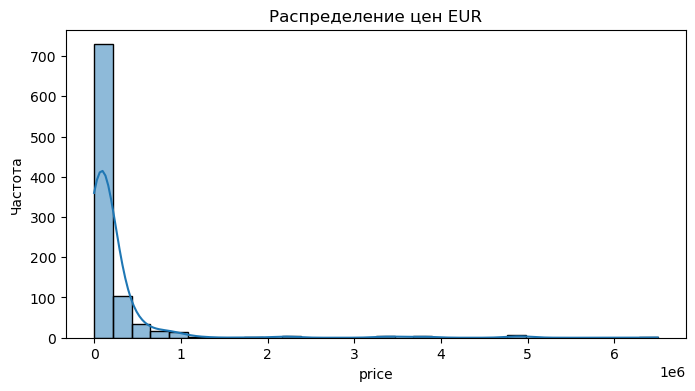


Валюта: GBP
n = 621
mean = 203455.50
median = 70000.00
std = 687363.38


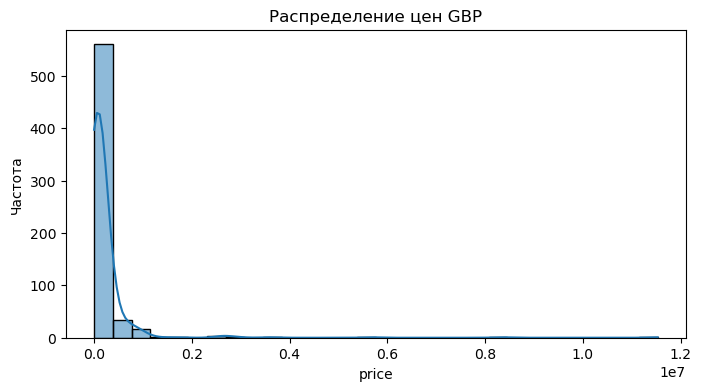


Валюта: TRY
n = 400677
mean = 354008.65
median = 200000.00
std = 4820978.16


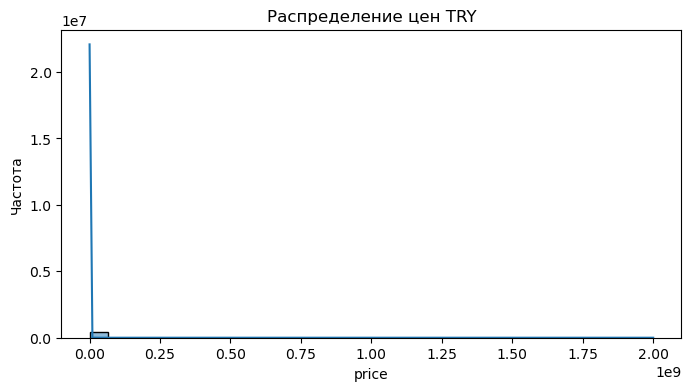


Валюта: USD
n = 552
mean = 1182746.44
median = 400000.00
std = 2391259.51


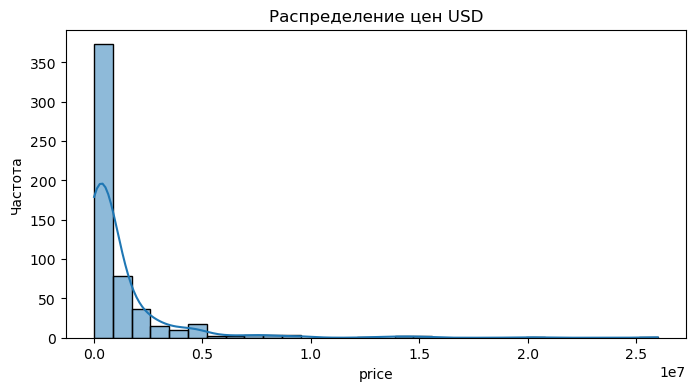

In [82]:
for cur, group in df.dropna(subset=['price']).groupby('price_currency'):
    prices = group['price']
    print(f'\nВалюта: {cur}')
    print(f'n = {len(prices)}')
    print(f'mean = {prices.mean():.2f}')
    print(f'median = {prices.median():.2f}')
    print(f'std = {prices.std():.2f}')

    plt.figure(figsize=(8, 4))
    sns.histplot(prices, bins=30, kde=True)
    plt.title(f'Распределение цен {cur}')
    plt.xlabel('price')
    plt.ylabel('Частота')
    plt.show()

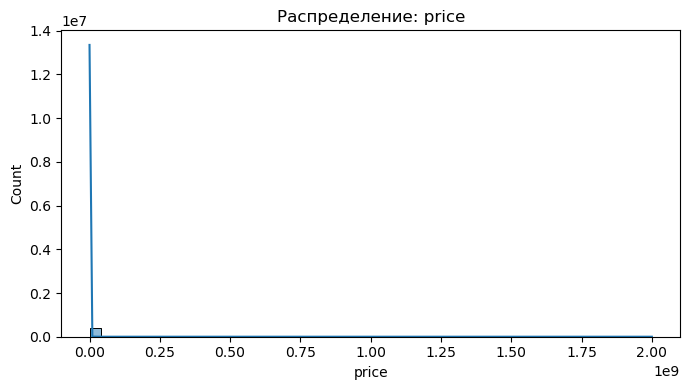

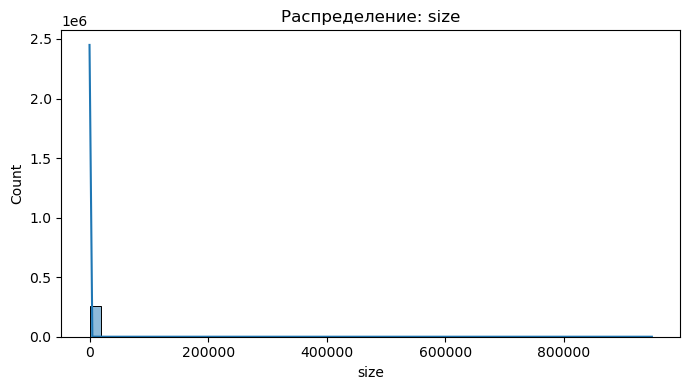

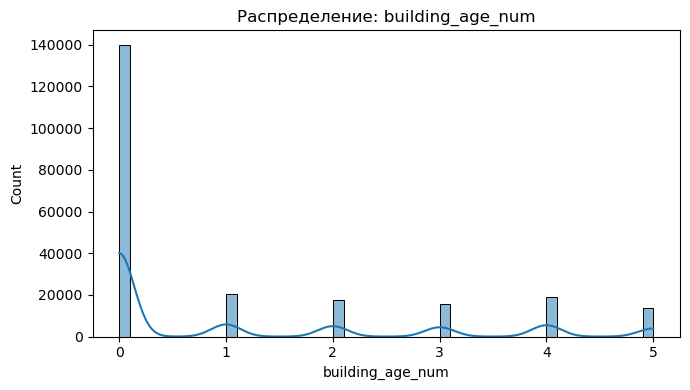

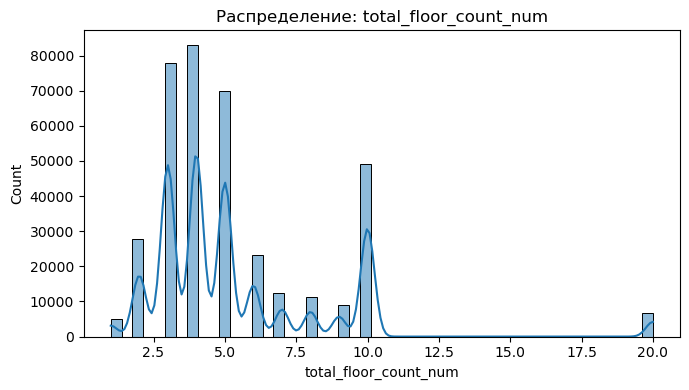

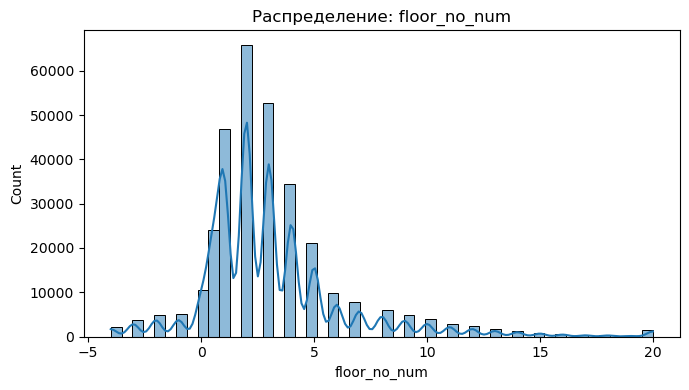

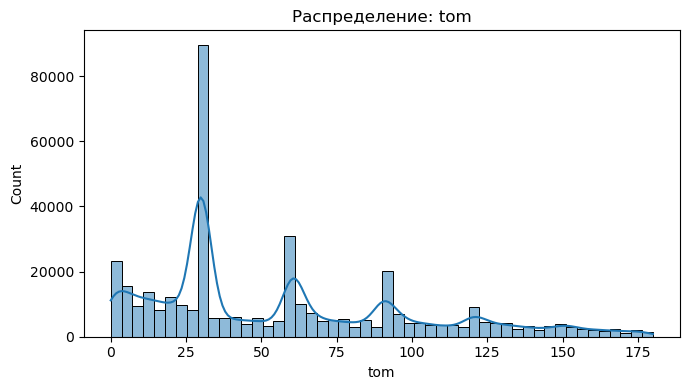

In [83]:
num_cols = [
    'price', 'size', 'building_age_num', 'total_floor_count_num',
    'floor_no_num', 'tom'
] # числовые признаки

for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col].dropna(), bins=50, kde=True)
    plt.title(f'Распределение: {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

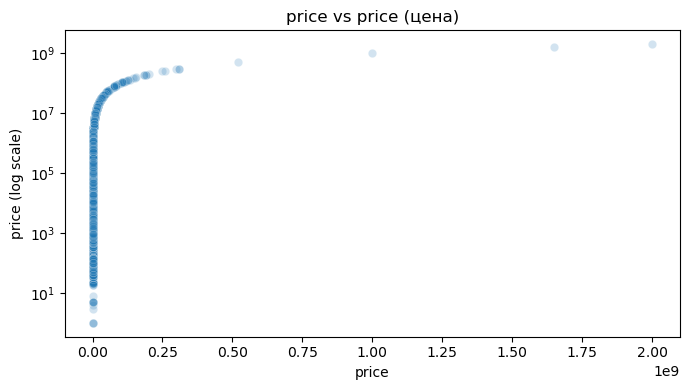

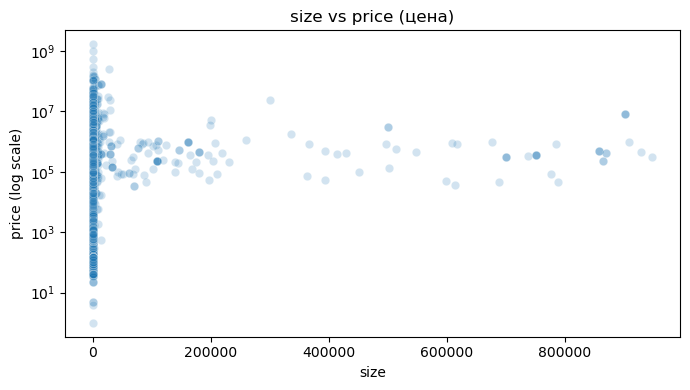

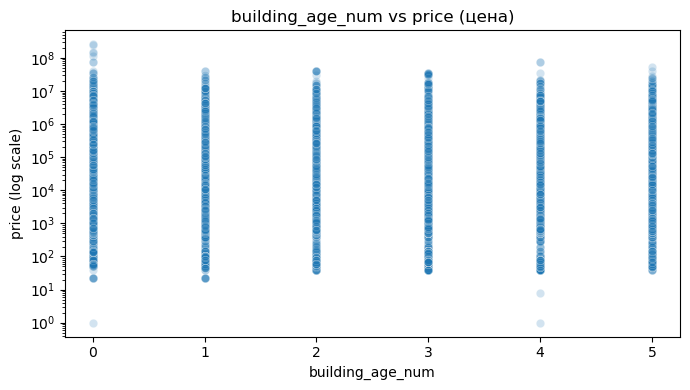

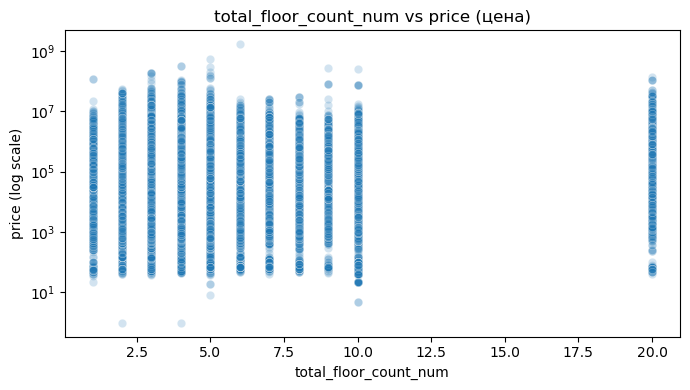

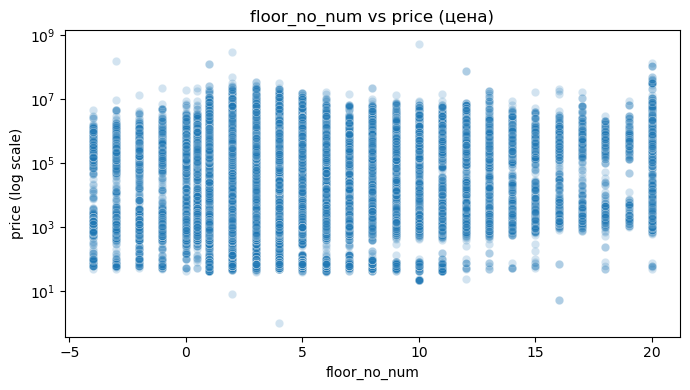

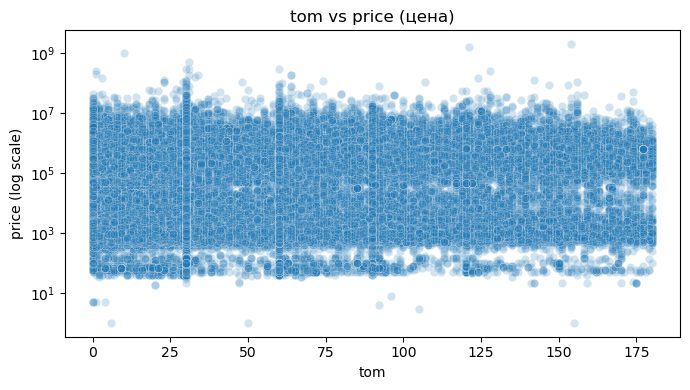

In [84]:
for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=df, x=col, y='price', alpha=0.2)
    plt.yscale('log')
    plt.title(f'{col} vs price (цена)')
    plt.xlabel(col)
    plt.ylabel('price (log scale)')
    plt.tight_layout()
    plt.show()

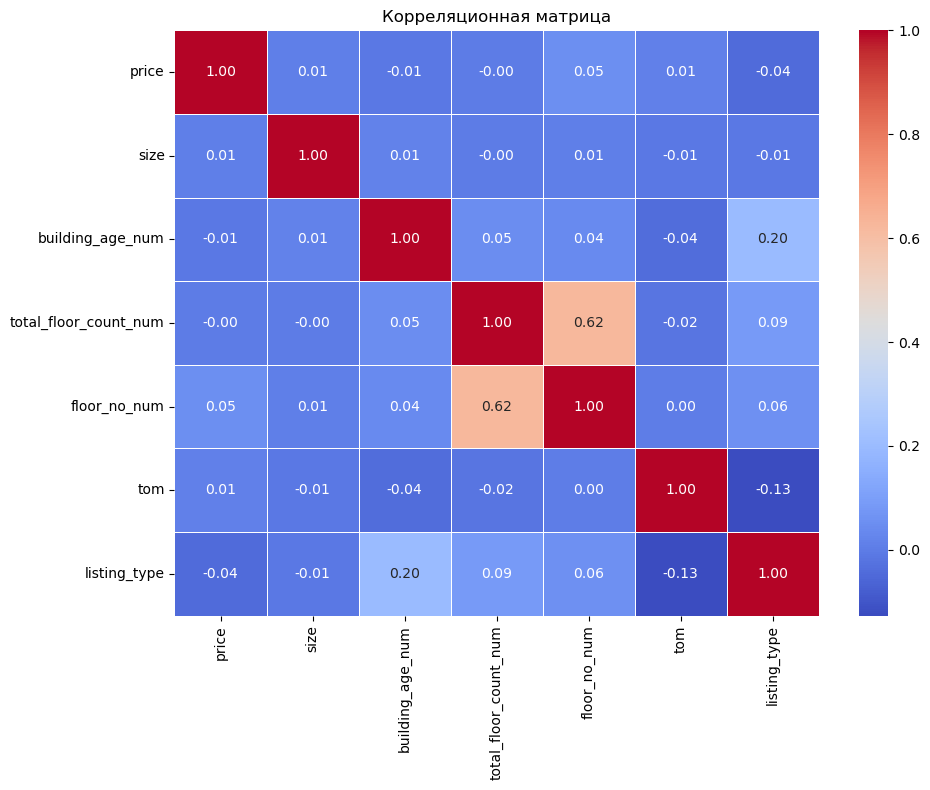

In [85]:
corr_cols = [
    'price', 'size', 'building_age_num', 'total_floor_count_num',
    'floor_no_num', 'tom', 'listing_type'
] # корреляционные признаки
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

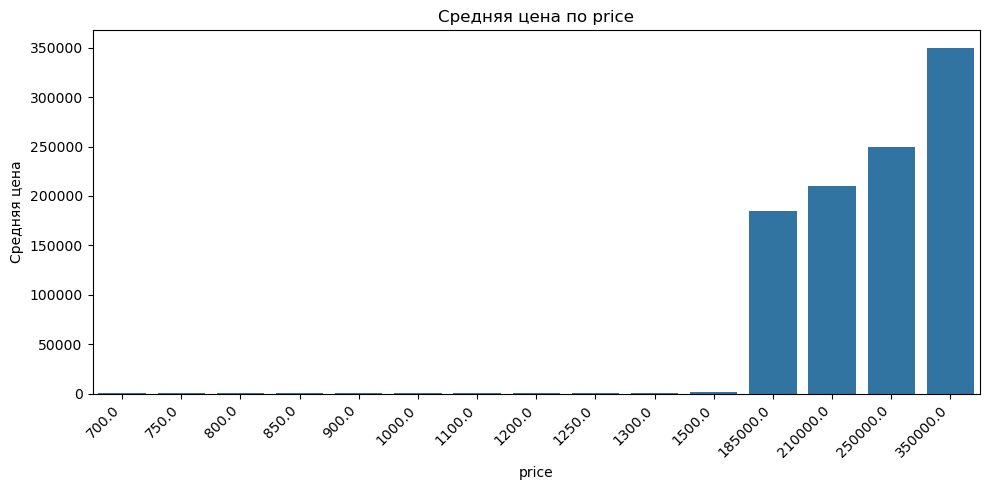

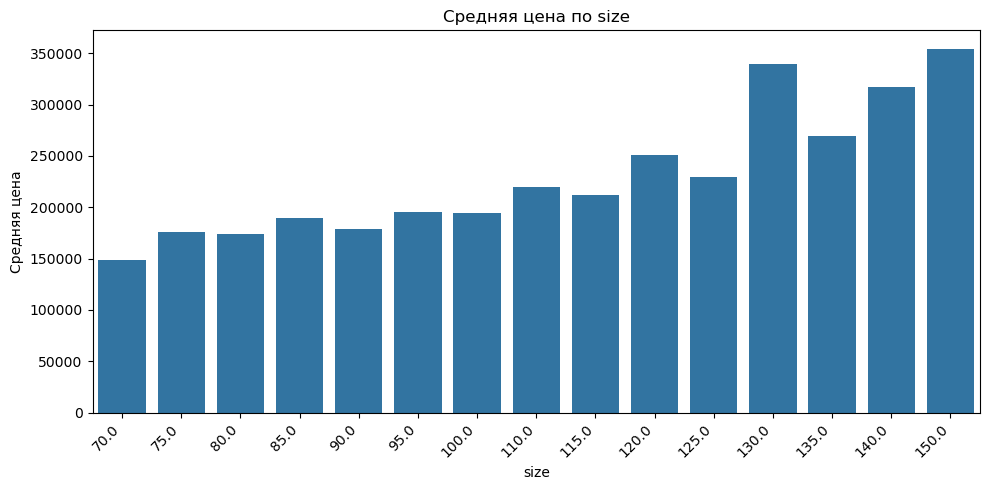

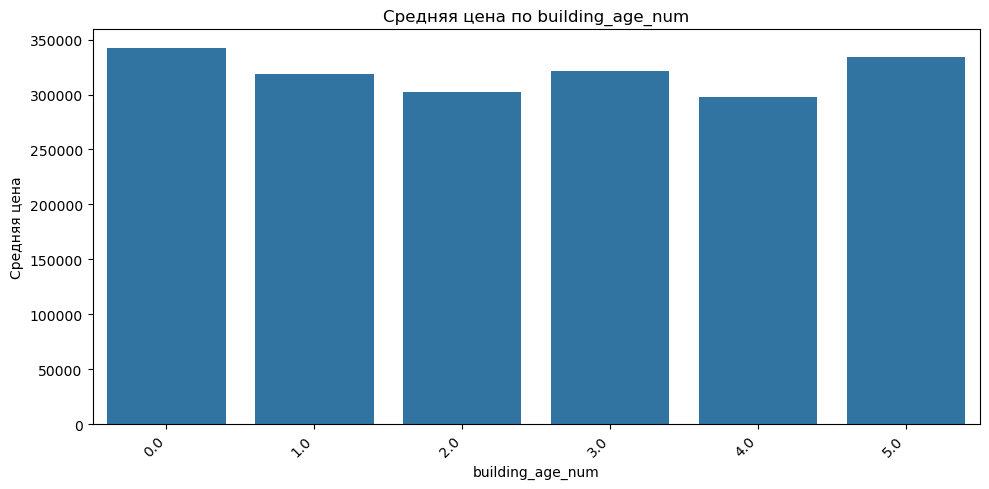

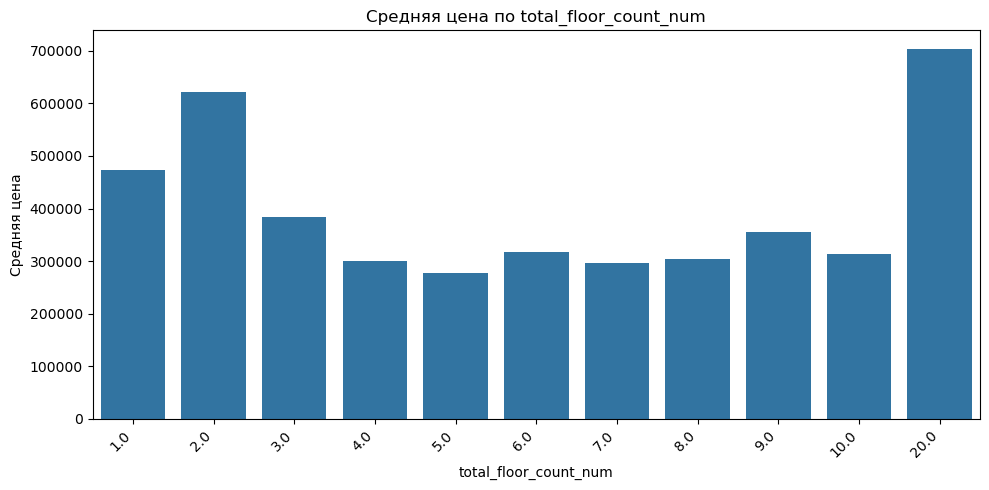

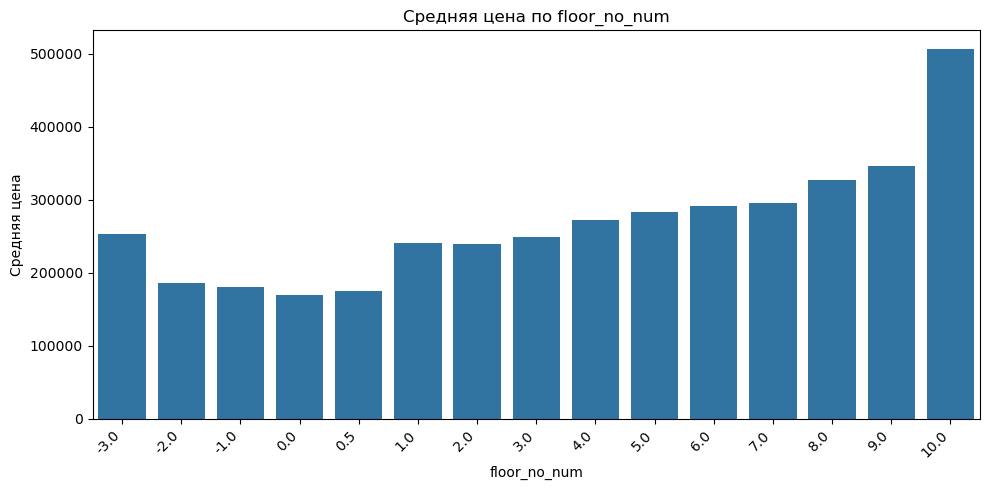

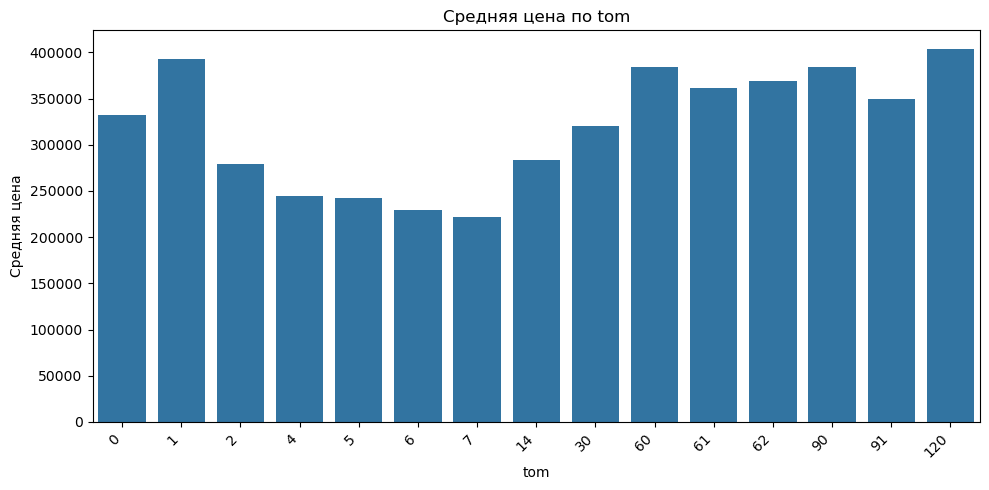

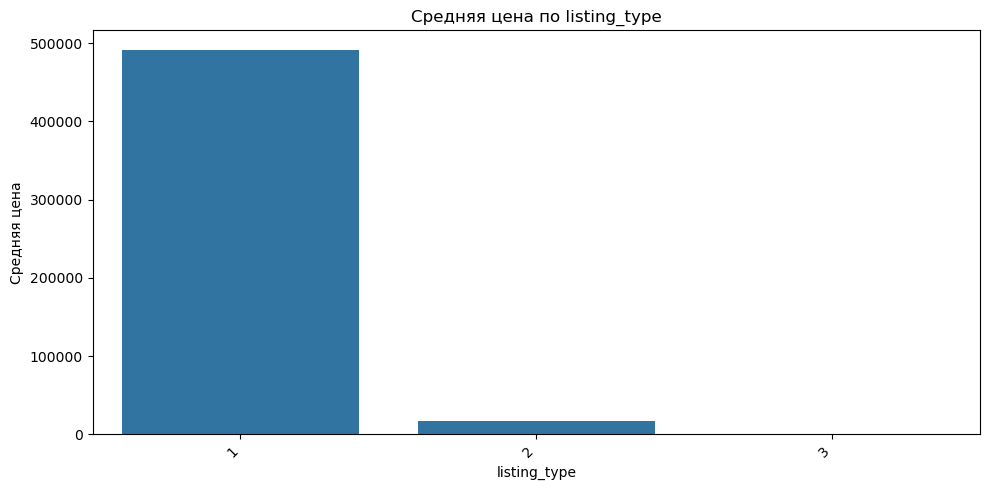

In [86]:
for col in corr_cols:
    tmp = (
        df.groupby(col)['price']
            .agg(['mean', 'median', 'count'])
            .reset_index()
            .sort_values('count', ascending=False)
            .head(15)
    )
    plt.figure(figsize=(10, 5))
    sns.barplot(data=tmp, x=col, y='mean')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Средняя цена по {col}')
    plt.ylabel('Средняя цена')
    plt.tight_layout()
    plt.show()

# Предварительная обработка данных

In [87]:
RATES = {"TRY": 1.0, "GBP": 42.0, "USD": 33.0, "EUR": 36.0}
df["price_try"] = df["price"] * df["price_currency"].map(RATES)

In [88]:
y = df["price_try"]

In [89]:
drop_cols = ["id", "price", "price_try", 
             "start_date", "end_date", "neighborhood"]
drop_cols = [c for c in drop_cols if c in df.columns]

In [90]:
X = df.drop(columns=drop_cols)

In [91]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

In [92]:
for c in X.select_dtypes(include=["float64"]).columns:
    X[c] = X[c].astype("float32")

In [93]:
# One Hot Encoding
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

def _to_str(df):
    return df.astype(str)

tree_pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("to_str", FunctionTransformer(
                _to_str,
                feature_names_out="one-to-one"
            )),
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                min_frequency=50,
                max_categories=100,
            ))
        ]), cat_cols),
    ], 
    remainder="drop" )

In [94]:
X.columns

Index(['type', 'sub_type', 'listing_type', 'tom', 'size', 'heating_type',
       'price_currency', 'building_age_num', 'room_total', 'floor_no_num',
       'total_floor_count_num', 'city', 'district'],
      dtype='object')

In [95]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 402772 entries, 0 to 403486
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   type                   402772 non-null  object 
 1   sub_type               402772 non-null  object 
 2   listing_type           402772 non-null  int64  
 3   tom                    402772 non-null  int64  
 4   size                   257380 non-null  float32
 5   heating_type           375192 non-null  object 
 6   price_currency         402772 non-null  object 
 7   building_age_num       226009 non-null  float32
 8   room_total             400446 non-null  float32
 9   floor_no_num           315890 non-null  float32
 10  total_floor_count_num  375123 non-null  float32
 11  city                   402772 non-null  object 
 12  district               402765 non-null  object 
dtypes: float32(5), int64(2), object(6)
memory usage: 35.3+ MB


# Построение модели регрессии

In [96]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import (
    RandomForestRegressor,
    BaggingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import ( # метрики
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

RANDOM_STATE = 42 # закрепление случайности

In [97]:
from sklearn.model_selection import train_test_split
# деление 80/20 train_full/test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)

In [98]:
X_search = X_train.sample(n=80_000, random_state=RANDOM_STATE)
y_search = y_train.loc[X_search.index]

In [99]:
print(X_train.shape, X_val.shape, X_test.shape)

(257773, 13) (64444, 13) (80555, 13)


In [100]:
print(X_search.shape, y_search.shape)

(80000, 13) (80000,)


In [101]:
models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=1,
        random_state=RANDOM_STATE
    ),
    "Bagging": BaggingRegressor(
        estimator=DecisionTreeRegressor(
            min_samples_leaf=2,
            random_state=RANDOM_STATE
        ),
        n_estimators=50,
        max_samples=0.7,
        max_features=0.8,
        n_jobs=1,
        random_state=RANDOM_STATE
    ),
    "Boosting": HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        early_stopping=True,
        random_state=RANDOM_STATE
    ),
}

In [102]:
param_grids = {
    "RandomForest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 20, 30],
        "model__min_samples_leaf": [1, 2, 5],
        "model__max_features": ["sqrt", 0.5],
    },

    "Bagging": {
        "model__n_estimators": [50, 100],
        "model__max_samples": [0.6, 0.8, 1.0],
        "model__max_features": [0.6, 0.8, 1.0],
        "model__estimator__max_depth": [None, 20, 30],
    },
    "Boosting": {
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_iter": [300, 500, 800],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__l2_regularization": [0.0, 1.0, 5.0],
    }
}

In [42]:
# обучение
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

best_models = {}
search_results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("pre", tree_pre),
        ("model", model)
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grids[name],
        n_iter=5,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=4,
        verbose=1,
        random_state=RANDOM_STATE
    )
    search.fit(X_search, y_search)
    best_models[name] = search.best_estimator_
    search_results[name] = {
        "best_params": search.best_params_,
        "best_cv_rmse": -search.best_score_
    }

    print(f"\n{name}")
    print("Лучшее CV RMSE:", -search.best_score_)
    print("Лучшие параметры:", search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits

RandomForest
Лучшее CV RMSE: 5427749.781410023
Лучшие параметры: {'model__n_estimators': 400, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20}
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Bagging
Лучшее CV RMSE: 5488245.375489035
Лучшие параметры: {'model__n_estimators': 100, 'model__max_samples': 0.6, 'model__max_features': 0.6, 'model__estimator__max_depth': 20}
Fitting 3 folds for each of 5 candidates, totalling 15 fits


  File "C:\Users\Radik\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Radik\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Radik\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Radik\anaconda3\Lib\subprocess.


Boosting
Лучшее CV RMSE: 5471310.062641954
Лучшие параметры: {'model__max_leaf_nodes': 31, 'model__max_iter': 500, 'model__learning_rate': 0.1, 'model__l2_regularization': 0.0}


In [44]:
def regression_metrics(y_true, y_pred, model_name="model"):
    y_pred = np.clip(y_pred, 0, None)
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

In [45]:
val_rows = []
for name, model in best_models.items():
    pred_val = model.predict(X_val)
    val_rows.append(regression_metrics(y_val, pred_val, name))
val_df = pd.DataFrame(val_rows).set_index("model").sort_values("RMSE")
print(val_df)

                        MAE          RMSE          MAPE        R2
model                                                            
Bagging       282269.735995  2.799929e+06  1.735934e+17  0.353294
RandomForest  260466.442421  2.802535e+06  1.497583e+17  0.352090
Boosting      299547.737289  3.018290e+06  9.687625e+16  0.248490


In [46]:
# Оценка на test:

test_rows = []
for name, model in best_models.items():
    pred_test = model.predict(X_test)
    test_rows.append(regression_metrics(y_test, pred_test, name))

test_df = pd.DataFrame(test_rows).set_index("model").sort_values("RMSE")
print(test_df)

                        MAE          RMSE          MAPE        R2
model                                                            
Bagging       296967.243659  6.577332e+06  5.523829e+17  0.119895
RandomForest  280170.368896  6.628939e+06  1.029631e+18  0.106030
Boosting      312489.978041  6.640010e+06  1.953255e+17  0.103042


In [47]:
# Сравнение:

comparison = val_df.join(test_df, lsuffix="_val", rsuffix="_test")
print(comparison.sort_values("RMSE_val"))

                    MAE_val      RMSE_val      MAPE_val    R2_val  \
model                                                               
Bagging       282269.735995  2.799929e+06  1.735934e+17  0.353294   
RandomForest  260466.442421  2.802535e+06  1.497583e+17  0.352090   
Boosting      299547.737289  3.018290e+06  9.687625e+16  0.248490   

                   MAE_test     RMSE_test     MAPE_test   R2_test  
model                                                              
Bagging       296967.243659  6.577332e+06  5.523829e+17  0.119895  
RandomForest  280170.368896  6.628939e+06  1.029631e+18  0.106030  
Boosting      312489.978041  6.640010e+06  1.953255e+17  0.103042  


In [48]:
# Сравнение моделей
print("Сравнение по validation:")
print(val_df)

print("\nСравнение по test:")
print(test_df)

print("\nЛучшая модель по validation RMSE:")
best_name = val_df.index[0]
print(best_name)

Сравнение по validation:
                        MAE          RMSE          MAPE        R2
model                                                            
Bagging       282269.735995  2.799929e+06  1.735934e+17  0.353294
RandomForest  260466.442421  2.802535e+06  1.497583e+17  0.352090
Boosting      299547.737289  3.018290e+06  9.687625e+16  0.248490

Сравнение по test:
                        MAE          RMSE          MAPE        R2
model                                                            
Bagging       296967.243659  6.577332e+06  5.523829e+17  0.119895
RandomForest  280170.368896  6.628939e+06  1.029631e+18  0.106030
Boosting      312489.978041  6.640010e+06  1.953255e+17  0.103042

Лучшая модель по validation RMSE:
Bagging


In [49]:
best_name = val_df.index[0]
final_model = clone(best_models[best_name])
final_model.fit(X_train_full, y_train_full)
final_pred = final_model.predict(X_test)
final_metrics = regression_metrics(y_test, final_pred, best_name)

print("Финальная модель:", best_name)
print(final_metrics)

Финальная модель: Bagging
{'model': 'Bagging', 'MAE': 271654.15342265094, 'RMSE': np.float64(6551191.326482154), 'MAPE': 7.618003384481637e+17, 'R2': 0.126877089332474}


In [3]:
import joblib

In [23]:
joblib.dump(final_model, '../data/best_model.pkl')  # Сохраняем лучшую модель

NameError: name 'final_model' is not defined

# Задание

Используемая модель для расчёта цены - Bagging. Bagging - это ансамблевый метод, который объединяет прогнозы из нескольких методов обучения вместе, чтобы предсказывать более точно. Идея бэгинга заключается в том, что каждый базовый алгоритм обучается на случайном подмножестве обучающей выборки. В этом случае, даже используя одну модель алгоритмов, получаются различные базовые алгоритмы.

Плюсы <br>
• Снижает переобучение и улучшает точность <br>
• Снижение дисперсии (variance) <br>
• Хорошо работает с категориальными и непрерывными значениями <br>
• Работает с высокоразмерными данными <br>


Минусы <br>
• Не дает точных непрерывных прогнозов в задачах регрессии <br>
• Управление моделью малое <br>
• Требует много времени для обучения модели <br>

"estimator=DecisionTreeRegressor(...)": В основе модели лежат решающие деревья. Бэггинг над деревьями решений работает по принципу, похожему на Random Forest, но с более гибкой настройкой подвыборок.

In [172]:
def _to_str(df):
    return df.astype(str)
main_model = joblib.load('../data/best_model.pkl')

In [173]:
test_df = pd.read_csv('../data/test_real_estate_samples.csv')

In [174]:
test_df.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,49,Konut,Kooperatif,11/10/18,12/10/18,1,30,0,10,Müstakil,1+0,1.0,İzmir/Aliağa/Yenişakran,NaN,Fancoil,300000.0,TRY
1,506,Konut,Çiftlik Evi,10/25/18,2/23/19,1,121,2,2,NaN,2+2,250.0,İzmir/Foça/Yeniköy,NaN,Yok,1600000.0,TRY
2,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
3,528,Konut,Prefabrik Ev,11/16/18,1/21/19,1,66,NaN,1,NaN,3+1,122.0,Tekirdağ/Çerkezköy/Kızılpınar,NaN,Yok,103600.0,TRY
4,109,Konut,Kooperatif,11/10/18,1/9/19,1,60,0,10,Müstakil,1+0,1.0,İzmir/Aliağa/Yenişakran,NaN,Fancoil,300000.0,TRY


In [175]:
RATES = {"TRY": 1.0, "GBP": 42.0, "USD": 33.0, "EUR": 36.0}

test_df = test_df.drop(columns=['furnished'])

test_df['building_age_num'] = pd.to_numeric(test_df['building_age'], errors='coerce')
test_df = test_df.drop(columns=['building_age'])

test_df['room_total'] = test_df['room_count'].apply(parse_room_count)
test_df = test_df.drop(columns=['room_count'])

test_df['floor_no_num'] = test_df['floor_no'].apply(parse_floor_no)
test_df = test_df.drop(columns=['floor_no'])

test_df['total_floor_count_num'] = (
            test_df['total_floor_count'].str.extract(r'(-?\d+\.?\d*)').astype(float)
)
test_df = test_df.drop(columns=['total_floor_count'])

test_df[['city', 'district', 'neighborhood']] = test_df['address'].str.split('/', expand=True)
test_df = test_df.drop(columns=['address'])

test_df['price_try'] = test_df['price'] * test_df['price_currency'].map(RATES)

In [176]:
test_df.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,size,heating_type,price,price_currency,building_age_num,room_total,floor_no_num,total_floor_count_num,city,district,neighborhood,price_try
0,49,Konut,Kooperatif,11/10/18,12/10/18,1,30,1.0,Fancoil,300000.0,TRY,0.0,1.0,NaN,10.0,İzmir,Aliağa,Yenişakran,300000.0
1,506,Konut,Çiftlik Evi,10/25/18,2/23/19,1,121,250.0,Yok,1600000.0,TRY,2.0,4.0,NaN,2.0,İzmir,Foça,Yeniköy,1600000.0
2,2,Konut,Daire,2/13/19,NaN,1,14,43.0,Fancoil,490000.0,TRY,0.0,1.0,20.0,20.0,İstanbul,Kartal,Kordonboyu,490000.0
3,528,Konut,Prefabrik Ev,11/16/18,1/21/19,1,66,122.0,Yok,103600.0,TRY,NaN,4.0,NaN,1.0,Tekirdağ,Çerkezköy,Kızılpınar,103600.0
4,109,Konut,Kooperatif,11/10/18,1/9/19,1,60,1.0,Fancoil,300000.0,TRY,0.0,1.0,NaN,10.0,İzmir,Aliağa,Yenişakran,300000.0


In [177]:
drop_cols = ["id", "price", "price_try", "start_date", "end_date", "neighborhood"]
drop_cols = [c for c in drop_cols if c in test_df.columns]

X_samples = test_df.drop(columns=drop_cols)
for c in X_samples.select_dtypes(include=["float64"]).columns:
    X_samples[c] = X_samples[c].astype("float32")
X_samples = X_samples.reindex(columns=X.columns)

In [178]:

X_samples.head()

,type,sub_type,listing_type,tom,size,heating_type,price_currency,building_age_num,room_total,floor_no_num,total_floor_count_num,city,district
0,Konut,Kooperatif,1,30,1.0,Fancoil,TRY,0.0,1.0,NaN,10.0,İzmir,Aliağa
1,Konut,Çiftlik Evi,1,121,250.0,Yok,TRY,2.0,4.0,NaN,2.0,İzmir,Foça
2,Konut,Daire,1,14,43.0,Fancoil,TRY,0.0,1.0,20.0,20.0,İstanbul,Kartal
3,Konut,Prefabrik Ev,1,66,122.0,Yok,TRY,NaN,4.0,NaN,1.0,Tekirdağ,Çerkezköy
4,Konut,Kooperatif,1,60,1.0,Fancoil,TRY,0.0,1.0,NaN,10.0,İzmir,Aliağa


In [179]:
y_pred_samples = np.clip(main_model.predict(X_samples), 0, None)
test_df['predicted_price_try'] = y_pred_samples

In [180]:
test_df['difference_price'] = test_df['predicted_price_try'].astype(int) - test_df['price_try']

In [181]:
test_df.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,size,heating_type,price,...,building_age_num,room_total,floor_no_num,total_floor_count_num,city,district,neighborhood,price_try,predicted_price_try,difference_price
0,49,Konut,Kooperatif,11/10/18,12/10/18,1,30,1.0,Fancoil,300000.0,...,0.0,1.0,NaN,10.0,İzmir,Aliağa,Yenişakran,300000.0,1.477975e+06,1177975.0
1,506,Konut,Çiftlik Evi,10/25/18,2/23/19,1,121,250.0,Yok,1600000.0,...,2.0,4.0,NaN,2.0,İzmir,Foça,Yeniköy,1600000.0,1.209743e+06,-390257.0
2,2,Konut,Daire,2/13/19,NaN,1,14,43.0,Fancoil,490000.0,...,0.0,1.0,20.0,20.0,İstanbul,Kartal,Kordonboyu,490000.0,3.635085e+05,-126492.0
3,528,Konut,Prefabrik Ev,11/16/18,1/21/19,1,66,122.0,Yok,103600.0,...,NaN,4.0,NaN,1.0,Tekirdağ,Çerkezköy,Kızılpınar,103600.0,4.087209e+05,305120.0
4,109,Konut,Kooperatif,11/10/18,1/9/19,1,60,1.0,Fancoil,300000.0,...,0.0,1.0,NaN,10.0,İzmir,Aliağa,Yenişakran,300000.0,1.490976e+06,1190975.0


In [182]:
y_true = test_df['price_try'].values.astype(float)
y_pred = test_df['predicted_price_try'].values.astype(float)

In [183]:
# Вручную
mae_manual  = np.mean(np.abs(y_true - y_pred))
rmse_manual = np.sqrt(np.mean((y_true - y_pred) ** 2))
res_manual = np.sum((y_true - y_pred) ** 2)
tot_manual = np.sum((y_true - y_true.mean()) ** 2)
r2_manual = 1 - res_manual / tot_manual

In [184]:
# Методами
mae_skl = mean_absolute_error(y_true, y_pred)
rmse_skl = np.sqrt(mean_squared_error(y_true, y_pred))
r2_skl = r2_score(y_true, y_pred)

In [185]:
metrics = pd.DataFrame({
    'Метрика': ['MAE', 'RMSE', 'R2'],
    'Вручную': [mae_manual, rmse_manual, r2_manual],
    'Метод': [mae_skl, rmse_skl, r2_skl],
})
print(metrics.to_string())

  Метрика        Вручную          Метод
0     MAE  392724.677272  392724.677272
1    RMSE  593836.039078  593836.039078
2      R2       0.094631       0.094631


In [186]:
test_df['mae'] = mae_skl
test_df['rmse_skl'] = rmse_skl
test_df['r2_skl'] = r2_skl
test_df['fio'] = 'Тухватуллин Р. Р.'
test_df['group'] = '23p-4'
test_df.head(20)

,id,type,sub_type,start_date,end_date,listing_type,tom,size,heating_type,price,...,district,neighborhood,price_try,predicted_price_try,difference_price,mae,rmse_skl,r2_skl,fio,group
0,49,Konut,Kooperatif,11/10/18,12/10/18,1,30,1.0,Fancoil,300000.0,...,Aliağa,Yenişakran,300000.0,1.477975e+06,1177975.0,392724.677272,593836.039078,0.094631,Тухватуллин Р. Р.,23p-4
1,506,Konut,Çiftlik Evi,10/25/18,2/23/19,1,121,250.0,Yok,1600000.0,...,Foça,Yeniköy,1600000.0,1.209743e+06,-390257.0,392724.677272,593836.039078,0.094631,Тухватуллин Р. Р.,23p-4
2,2,Konut,Daire,2/13/19,NaN,1,14,43.0,Fancoil,490000.0,...,Kartal,Kordonboyu,490000.0,3.635085e+05,-126492.0,392724.677272,593836.039078,0.094631,Тухватуллин Р. Р.,23p-4
3,528,Konut,Prefabrik Ev,11/16/18,1/21/19,1,66,122.0,Yok,103600.0,...,Çerkezköy,Kızılpınar,103600.0,4.087209e+05,305120.0,392724.677272,593836.039078,0.094631,Тухватуллин Р. Р.,23p-4
4,109,Konut,Kooperatif,11/10/18,1/9/19,1,60,1.0,Fancoil,300000.0,...,Aliağa,Yenişakran,300000.0,1.490976e+06,1190975.0,392724.677272,593836.039078,0.094631,Тухватуллин Р. Р.,23p-4
5,100,Konut,Yazlık,1/12/19,NaN,1,46,150.0,Fancoil,500000.0,...,Erdemli,Kargıpınarı,500000.0,6.206702e+05,120670.0,392724.677272,593836.039078,0.094631,Тухватуллин Р. Р.,23p-4
6,320,Konut,Yazlık,2/12/19,2/12/19,1,0,134.0,Fancoil,1000000.0,...,Burhaniye,Pelitköy,1000000.0,9.079650e+05,-92036.0,392724.677272,593836.039078,0.094631,Тухватуллин Р. Р.,23p-4
7,3,Konut,Daire,10/9/18,11/8/18,1,30,NaN,Fancoil,155000.0,...,Çorlu,Reşadiye,155000.0,5.716639e+05,416663.0,392724.677272,593836.039078,0.094631,Тухватуллин Р. Р.,23p-4
8,7810,Konut,Loft,12/30/18,1/29/19,1,30,145.0,Kalorifer (Doğalgaz),650000.0,...,Konak,Akın Simav,650000.0,6.785351e+05,28535.0,392724.677272,593836.039078,0.094631,Тухватуллин Р. Р.,23p-4
9,11,Konut,Müstakil Ev,11/13/18,11/26/18,1,13,125.0,Fancoil,2450000.0,...,Bodrum,Ortakentyahşi,2450000.0,2.438301e+06,-11700.0,392724.677272,593836.039078,0.094631,Тухватуллин Р. Р.,23p-4


In [187]:
test_df.to_csv('../data/result_real_estate_samples.csv', index=False)